## Recuperer et afficher les vecteur de Text

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import oracledb
import json
import array

# Connexion Oracle
conn = oracledb.connect(user="ryan", password="ryan23", dsn="localhost:1521/FREEPDB1")
cursor = conn.cursor()
# Récupération des vecteurs
cursor.execute("SELECT id, description, vector FROM patient_cases")
data = cursor.fetchall()

vectors = []
labels = []

for row in data:
    vec = row[2]  # colonne vector
    try:
        if isinstance(vec, oracledb.LOB):        # --- Si c’est un LOB (CLOB/BLOB) ---
            vec = vec.read()
        if isinstance(vec, str):                 # --- Si c’est une chaîne JSON ---
            vec = json.loads(vec)
        elif isinstance(vec, array.array):       # --- Si c’est un array.array ---
            vec = list(vec)
        elif isinstance(vec, list):              # --- Si c’est déjà une liste ---
            pass 
        else:                                    # --- Sinon format inconnu ---
            print(f" Erreur sur ID {row[0]}: format inattendu ({type(vec)})")
            continue
        
        # Vérification du contenu
        if isinstance(vec, list) and len(vec) > 0:
            vectors.append(vec)
            labels.append(f"ID {row[0]}")
            clob_content = row[1].read()          # lire le contenu du CLOB description
            description_preview = (clob_content[:30] + '...') if len(clob_content) > 30 else clob_content
        else:
            print(f" Erreur sur ID {row[0]}: vecteur vide ou invalide")
    except Exception as e:
        print(f" Erreur sur ID {row[0]}: {e}")

print(f" {len(vectors)} vecteurs récupérés")


 11049 vecteurs récupérés


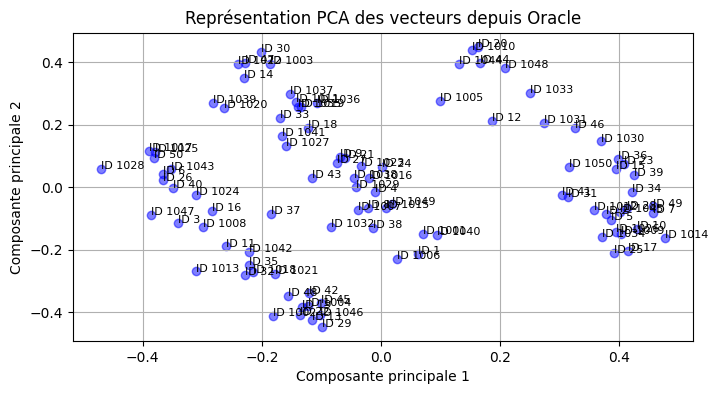

In [222]:

# Représentation PCA si vecteurs valides
if vectors:
    X = np.array(vectors[:100])  # Limite à 100 vecteurs pour la visualisation
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    plt.figure(figsize=(8, 4))
    plt.scatter(reduced[:, 0], reduced[:, 1], marker='o', color='blue', alpha=0.5)
    for i, label in enumerate(labels[:100]):
        plt.annotate(label, (reduced[i, 0], reduced[i, 1]), fontsize=8)
    plt.title("Représentation PCA des vecteurs depuis Oracle")
    plt.xlabel("Composante principale 1")
    plt.ylabel("Composante principale 2")
    plt.grid(True)
    plt.show()
else:
    print(" Aucun vecteur valide à afficher.")


## Recuperer et afficher les vecteur Image

 1504 vecteurs récupérés
 Affichage de 100 vecteurs pour la visualisation PCA


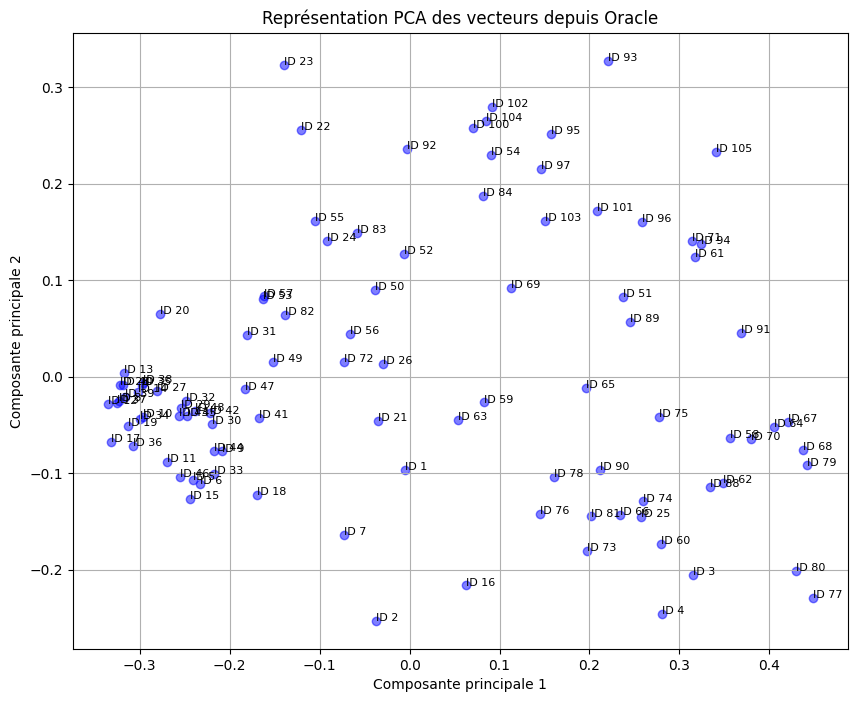

In [209]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import oracledb
import json
import array

# Connexion Oracle
conn = oracledb.connect(user="ryan", password="ryan23", dsn="localhost:1521/FREEPDB1")
cursor = conn.cursor()

# Récupération des vecteurs
cursor.execute("SELECT image_id, image_name, embedding FROM DIABETIC_RETINOPATHY_DIAGNOSIS")
data = cursor.fetchall()

vectors = []
labels = []

for row in data:
    vec = row[2]  # colonne vector
    try:
        # --- Si c’est un LOB (CLOB/BLOB) ---
        if isinstance(vec, oracledb.LOB):
            vec = vec.read()
        # --- Si c’est une chaîne JSON ---
        if isinstance(vec, str):
            vec = json.loads(vec)
        # --- Si c’est un array.array ---
        elif isinstance(vec, array.array):
            vec = list(vec)
        # --- Si c’est déjà une liste ---
        elif isinstance(vec, list):
            pass  # rien à faire
        # --- Sinon format inconnu ---
        else:
            print(f" Erreur sur ID {row[0]}: format inattendu ({type(vec)})")
            continue
        # Vérification du contenu
        if isinstance(vec, list) and len(vec) > 0:
            vectors.append(vec)
            labels.append(f"ID {row[0]}")
        else:
            print(f" Erreur sur ID {row[0]}: vecteur vide ou invalide")

    except Exception as e:
        print(f" Erreur sur ID {row[0]}: {e}")

print(f" {len(vectors)} vecteurs récupérés")

# Représentation PCA si vecteurs valides
if vectors:
    print(f" Affichage de {min(100, len(vectors))} vecteurs pour la visualisation PCA")
    X = np.array(vectors[:100])  
    pca = PCA(n_components=20)
    reduced = pca.fit_transform(X)

    plt.figure(figsize=(10, 8))
    plt.scatter(reduced[:, 0], reduced[:, 1], marker='o', color='blue', alpha=0.5)
    for i, label in enumerate(labels[:100]):
        plt.annotate(label, (reduced[i, 0], reduced[i, 1]), fontsize=8)
    plt.title("Représentation PCA des vecteurs depuis Oracle")
    plt.xlabel("Composante principale 1")
    plt.ylabel("Composante principale 2")
    plt.grid(True)
    plt.show()
else:
    print(" Aucun vecteur valide à afficher.")


#K-MEANS

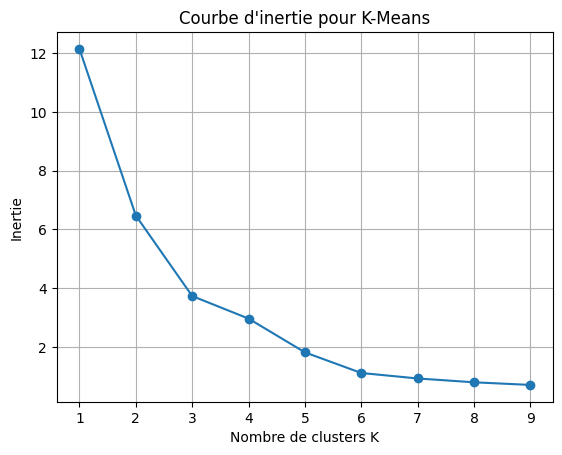

In [223]:

# ficher le graph de la courbe d'insetia gain de K-Means
inertia_values = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(reduced)
    inertia_values.append(kmeans.inertia_)
plt.plot( range(1, 10),inertia_values,  marker='o')
plt.title("Courbe d'inertie pour K-Means")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie")
plt.grid(True)

In [215]:
from sklearn.cluster import KMeans

# On choisit le nombre de clusters 
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(reduced)

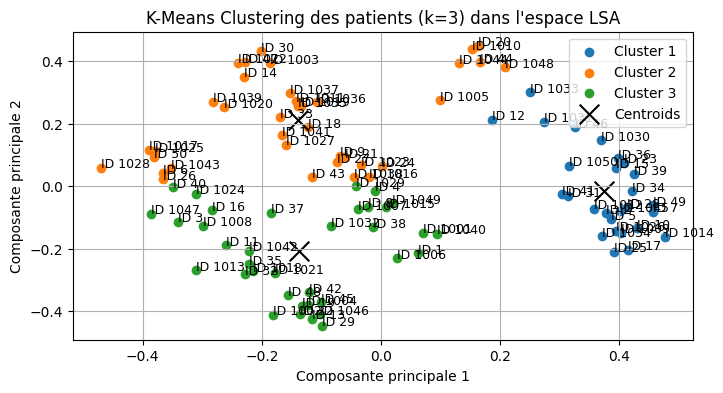

In [216]:
# Affichage des clusters
plt.figure(figsize=(8, 4))

# Affichage des documents avec leur cluster
for i in range(k):
    plt.scatter(reduced[clusters == i, 0], reduced[clusters == i, 1], label=f'Cluster {i+1}')

# Affichage des centres de cluster
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='x', color='black', s=200, label='Centroids')

# Affichage de la requête
#plt.scatter(query_lsi[0, 0], query_lsi[0, 1], marker='*', color='red', s=150, label='Query')

# Étiquettes
for i, txt in enumerate(labels[:100]):
    plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=9)

plt.title(f"K-Means Clustering des patients (k={k}) dans l'espace LSA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.grid(True)
plt.show()


## DBSCAN sur les donneés de text

In [217]:
from sklearn.cluster import DBSCAN
# DBSCAN avec des paramètres initiaux 
dbscan = DBSCAN(eps=0.3, min_samples=29, metric='cosine')
db_labels = dbscan.fit_predict(reduced)


C:\Program Files\KMSpico\temp\ipykernel_12072\2018310039.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


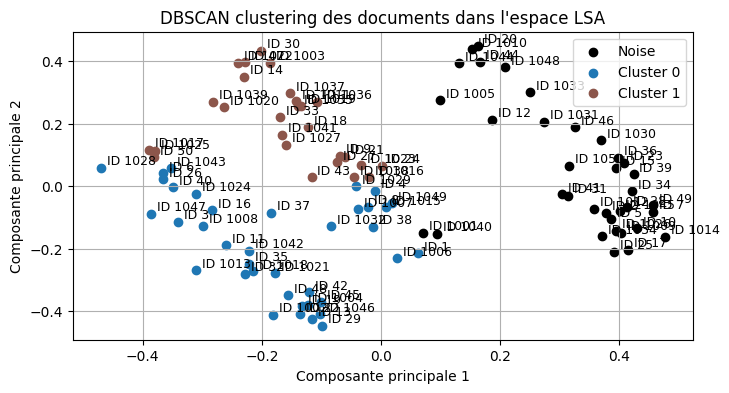

In [218]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 4))
# Affichage des points avec couleur selon leur cluster
unique_labels = np.unique(db_labels)
colors = plt.cm.get_cmap("tab10", len(unique_labels))

for label in unique_labels:
    mask = db_labels == label
    color = 'black' if label == -1 else colors(label)
    plt.scatter(reduced[mask, 0], reduced[mask, 1], label=f"Cluster {label}" if label != -1 else "Noise", c=[color])
# Affichage des étiquettes
for i, txt in enumerate(labels[:100]):
    plt.annotate(txt, (reduced[i, 0]+0.01, reduced[i, 1]+0.01), fontsize=9)

plt.title("DBSCAN clustering des documents dans l'espace LSA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.grid(True)
plt.show()


In [219]:
description_previews = []
for row in data:  # rows = liste des résultats de la DB
    clob_content = row[1].read() if hasattr(row[1], 'read') else row[1]
    preview = (clob_content[:200] + '...') if len(clob_content) > 200 else clob_content
    description_previews.append(preview)


In [220]:
for label in unique_labels:
    print(f"\n Cluster {label if label != -1 else 'Noise'}:")
    for i in range(len(labels[:100])):
        if db_labels[i] == label:
            print(f" - Doc{i+1}: {description_previews[i]}")


 Cluster Noise:
 - Doc2: 35-year-old pregnant woman (12 weeks gestation) with severe nausea.
 - Doc4: 32-year-old woman suffering from chronic migraines triggered by stress and lack of sleep.
 - Doc7: 28-year-old woman presenting with acute urinary tract infection with burning during urination.
 - Doc9: 40-year-old woman with moderate postpartum depression.
 - Doc11: 38-year-old woman with severe seasonal allergy.
 - Doc14: 65-year-old woman with advanced osteoporosis.
 - Doc15: 29-year-old woman with severe acne.
 - Doc19: 50-year-old woman with prediabetes and overweight.
 - Doc22: 56-year-old hypertensive woman, sudden vertigo attack with visual disturbances.
 - Doc25: 25-year-old woman with generalized anxiety and sleep disorders.
 - Doc27: 33-year-old woman with right shoulder tendinitis.
 - Doc29: 46-year-old woman with morbid obesity.
 - Doc32: 27-year-old woman with recurrent cystitis.
 - Doc34: 48-year-old woman with symptomatic menopause.
 - Doc38: 45-year-old woman with irr

In [ ]:
#Analyse de texte médical pour identifier les diagnostics les plus fréquents.
from collections import Counter
diagnoses = [row[1].read() if hasattr(row[1], 'read') else row[1] for row in data]
diagnosis_counts = Counter(diagnoses)
diagnosis_counts.most_common(10)



[('20-year-old patient presenting with ocular irritation', 4),
 ('84-year-old patient presenting with muscle stiffness', 3),
 ('79-year-old man presenting with muscle stiffness', 3),
 ('72-year-old woman presenting with seasonal allergies', 3),
 ('50-year-old patient presenting with skin rash of unknown origin', 3),
 ('20-year-old woman presenting with acute bronchitis', 3),
 ('37-year-old patient presenting with chronic hypertension', 3),
 ('68-year-old patient presenting with chronic sinus infection', 2),
 ('86-year-old woman presenting with muscle stiffness', 2),
 ('49-year-old woman presenting with moderate asthma', 2)]